In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.style.use('seaborn-v0_8')

# 0. Preparation

## 0.1 Parameters

In [2]:
price_AMZN = 231
price_SPX = 6600
div_rate_AMZN = 0
div_rate_SPX = 1.3/100
risk_free_rate = 4.8/100
time_to_maturity = 105/365
rho = 0.5

corr_matrix = np.array([
    [1.0, rho],
    [rho, 1.0]
])

SEED = 42

## 0.2 Data loading

In [3]:
data = pd.read_excel('./vol_data.xlsx', usecols='A, B, E, F', skiprows=2)
data.columns = ['SPX_STR', 'SPX_IV', 'AMZN_STR', 'AMZN_IV']
spx = data[['SPX_STR', 'SPX_IV']].dropna()
amzn = data[['AMZN_STR', 'AMZN_IV']].dropna()
display(spx.describe())
display(amzn.describe())

,SPX_STR,SPX_IV
count,241.000000,241.000000
mean,6020.273859,0.204989
std,882.804725,0.082619
min,3802.000000,0.116796
25%,5475.000000,0.132243
50%,6066.000000,0.187300
75%,6657.000000,0.250705
max,8724.000000,0.460000


,AMZN_STR,AMZN_IV
count,277.000000,277.000000
mean,210.262708,0.371820
std,48.665271,0.083142
min,110.740000,0.297849
25%,175.080000,0.308061
50%,217.660000,0.337806
75%,250.300000,0.418296
max,318.900000,0.610300


In [4]:
amzn_strikes = amzn.AMZN_STR.to_numpy()
amzn_iv = amzn.AMZN_IV.to_numpy()
spx_strikes = spx.SPX_STR.to_numpy()
spx_iv = spx.SPX_IV.to_numpy()

## 0.3 Converting into call prices

In [5]:
def call_value(S0: int, strikes: np.ndarray, T: float, r: float, q: float, ivs: np.ndarray) -> np.ndarray:
    d1 = (np.log(S0/strikes)+(r-q+0.5*ivs**2)*T)/(ivs*np.sqrt(T))
    d2 = d1 - ivs*np.sqrt(T)
    Cs = S0*np.exp(-q*T)*norm.cdf(d1) - strikes*np.exp(-r*T)*norm.cdf(d2)
    return Cs

amzn_calls = call_value(price_AMZN, amzn_strikes, time_to_maturity, risk_free_rate, div_rate_AMZN, amzn_iv)
spx_calls = call_value(price_SPX, spx_strikes, time_to_maturity, risk_free_rate, div_rate_SPX, spx_iv)

## 0.4 constructing $F^{-1}$

In [6]:
def construct_inv_F(call_prices: np.ndarray, strikes: np.ndarray, r: float, T: float) -> Callable[[np.ndarray], np.ndarray]: 
    dC_dK = np.gradient(call_prices, strikes, edge_order=2)
    F = 1.0 + np.exp(r*T) * dC_dK
    F = np.clip(F, 0.0, 1.0) # ensure CDF properties
    F = np.maximum.accumulate(F)
    F = (F - F[0])/(F[-1] - F[0]) # normalize
    
    # We assume the possibilities are constrained by the given excel and 
    # don't build additional data to reach call/put values of 0 (extending the strikes grid)

    F_unique, indices = np.unique(F, return_index=True)
    K_unique = strikes[indices]

    def inv_F(u: np.ndarray) -> np.ndarray:
        return  np.interp(u, F_unique, K_unique)

    return inv_F

inv_F_amzn = construct_inv_F(amzn_calls, amzn_strikes, risk_free_rate, time_to_maturity)
inv_F_spx = construct_inv_F(spx_calls, spx_strikes, risk_free_rate, time_to_maturity)

# Exercise 1

## 1.1 Getting uniform samples

In [7]:
def draw_gaussian_copula(n_samples: int, correlation_matrix: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)

    normal_samples = rng.multivariate_normal(
        mean = np.zeros(2),
        cov = correlation_matrix,
        size = n_samples
    )

    uniform_samples = norm.cdf(normal_samples)
    return uniform_samples

N_SAMPLES = 10_000

uniform_samples = draw_gaussian_copula(N_SAMPLES, corr_matrix, SEED)

U_spx = uniform_samples[:, 0]
U_amzn = uniform_samples[:, 1]

## 1.2 Applying $F^{-1}$

In [8]:
ST_spx = inv_F_spx(U_spx)
ST_amzn = inv_F_amzn(U_amzn)

## 1.3 Implied CDFs

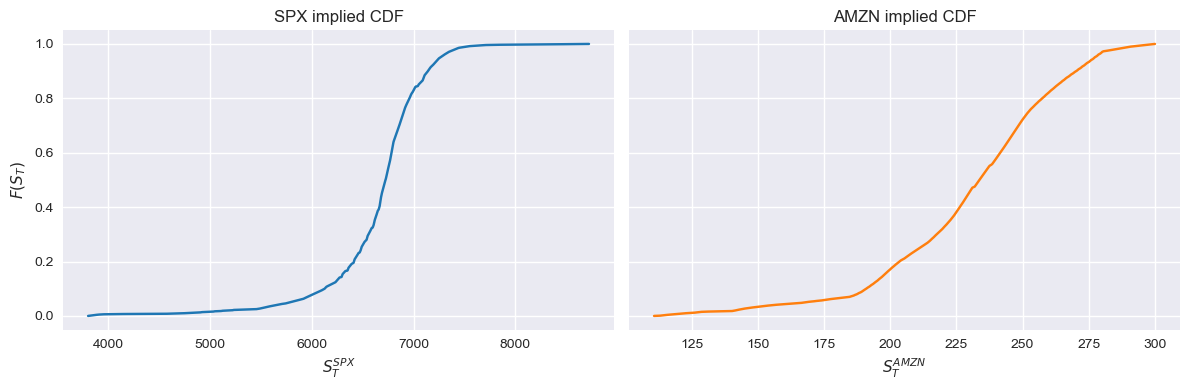

In [9]:
cdf_probabilities = np.linspace(0.0, 1.0, 1_000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(inv_F_spx(cdf_probabilities), cdf_probabilities, color='tab:blue')
axes[0].set_title('SPX implied CDF')
axes[0].set_xlabel(r'$S_T^{SPX}$')
axes[0].set_ylabel(r'$F(S_T)$')

axes[1].plot(inv_F_amzn(cdf_probabilities), cdf_probabilities, color='tab:orange')
axes[1].set_title('AMZN implied CDF')
axes[1].set_xlabel(r'$S_T^{AMZN}$')

fig.tight_layout()
plt.show()

## 1.4 Calculate payoffs

In [10]:
spx_returns = ST_spx/price_SPX
amzn_returns = ST_amzn/price_AMZN

payoffs = np.maximum(spx_returns - amzn_returns, 0.0) # our option payoff

## 1.5 Current price and SE

In [11]:
discount_factor = np.exp(-risk_free_rate*time_to_maturity)

option_price = discount_factor*np.mean(payoffs)

standard_error = (discount_factor*np.std(payoffs, ddof=1)/np.sqrt(N_SAMPLES))
# need to specify ddof=1 for unbiased with numpy, not if it was pandas

print(f"Option price: {option_price:.6f}")
print(f"Standard error: {standard_error:.6f}")

Option price: 0.052997
Standard error: 0.000869


# Exercise 2

## 2.0 Specific parameters

In [12]:
K = 218**2

## 2.1 Uniform Samples

In [13]:
def draw_uniform_samples(n_samples: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)  
    return rng.uniform(0.0, 1.0, n_samples)

uniform_samples = draw_uniform_samples(N_SAMPLES, SEED)

## 2.2 Applying $F^{-1}$

In [14]:
ST_amzn_2 = inv_F_amzn(uniform_samples)

## 2.3 Calculate payoffs

In [15]:
value = K - ST_amzn_2**2
payoffs_2 = np.maximum(value, 0)

## 2.4 Current price and SE

In [16]:
option_price_2 = discount_factor*np.mean(payoffs_2)

standard_error_2 = (discount_factor*np.std(payoffs_2, ddof=1)/np.sqrt(N_SAMPLES))

print(f"Option price: {option_price_2:.6f}")
print(f"Standard error: {standard_error_2:.6f}")

Option price: 3204.826536
Standard error: 67.399098
